# 02. pandas & NumPy Basics
## 📚 Learning Objectives

By completing this notebook, you will:
- Create and manipulate NumPy arrays and pandas DataFrames
- Use groupby, describe, and basic indexing
- Produce simple plots and link to Example 3

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 01 "Python Libraries for AI" — the same NumPy and pandas, now as the primary working surface rather than a support library.

**Used later in:** Course 05 — Unit 2 onwards; every notebook in this course is pandas, and Course 04 (AIAT 114)'s preprocessing pipelines assume it.

---


## 🎯 Why these two libraries exist — and one spreadsheet that lost 15,841 people

**NumPy.** When the Event Horizon Telescope published the first image of a black hole in
2019 and when LIGO announced the detection of gravitational waves, NumPy was in the stack
that produced both. That is not marketing: it is stated in the reference paper for the
library itself — Harris et al., *"Array programming with NumPy"*, Nature 585, 357–362
(2020): *"in astronomy, NumPy was an important part of the software stack used in the
discovery of gravitational waves and the first imaging of a black hole."*

**pandas.** Wes McKinney started writing it in 2008 while a researcher at **AQR Capital
Management**, because the fund needed a fast, flexible way to do quantitative analysis on
financial data that spreadsheets could not give them. He convinced management to open-source
it in 2009. Every `groupby` you write below descends from that specific business need.

**What goes wrong without them — England, autumn 2020.** Public Health England collated
COVID-19 test results from laboratories into Excel templates saved in the legacy **`.xls`**
format, which stops at **65,536 rows**. When a file filled up, the extra results were not
flagged — they were silently dropped. Between 25 September and 2 October 2020, **15,841
positive cases** never reached contact tracing, and tens of thousands of their contacts
were never warned. Nothing about that failure required a hard algorithm. It required a
table that does not silently truncate, and a language that raises an error instead of
shrugging. That is what you are learning here.

Below you work on the **Titanic passenger manifest** — 891 real passenger records from the
sinking of 15 April 1912, in which about 1,500 of the roughly 2,200 people aboard died and
around 710 survivors were picked up by the *Carpathia*. (The 1912 British and American
inquiries published slightly different totals; historians still argue over the exact
figures, which is itself a data-provenance lesson.) The `Age` column is blank for 177 of them because the
record genuinely does not say. Then, for the timing experiment, you switch to **CIC-IDS2017**,
five days of real network traffic captured at the Canadian Institute for Cybersecurity
(University of New Brunswick), 3–7 July 2017.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Solving the Problem from Example 1

**Remember the dead end from Example 1?**
- We understood the data science lifecycle conceptually
- But we didn't know **how** to actually manipulate data in Python
- We needed practical tools and techniques

**This notebook solves that problem!**
- We'll learn **pandas** - the tool for working with DataFrames (tables)
- We'll learn **NumPy** - the tool for numerical operations and arrays
- We'll learn **data manipulation techniques** - filtering, grouping, transforming

**This is the bridge between understanding the lifecycle and actually implementing it!**

---

## The Story: Learning Your Tools

Imagine you're a carpenter. **Before** building furniture, you need to learn your tools - what a hammer does, how to use a saw, when to use a screwdriver. **After** mastering your tools, you can build anything!

Same with data science: **Before** analyzing data, we learn our tools - pandas for tables, NumPy for arrays, when to use each. **After** mastering these tools, we can work with any data!

---

## Why pandas & NumPy Matter

These libraries are essential because:
- **pandas**: The standard tool for working with tables (DataFrames)
- **NumPy**: The foundation for all numerical computing in Python
- **Together**: scikit-learn, matplotlib, seaborn and statsmodels all take NumPy arrays
  or pandas objects as their input — learning these two is the entry ticket to the rest
- **Performance**: NumPy is fast, pandas makes it easy

## Learning Objectives
1. Create and manipulate NumPy arrays (1D and 2D)
2. Perform NumPy operations (mean, std, sum, min, max)
3. Create pandas DataFrames from dictionaries
4. Select, filter, and transform data
5. Use GroupBy operations for aggregations
6. Create visualizations of your data


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- NumPy arrays, DataFrames, groupby, basic viz
- Libraries: pandas, numpy, matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- Array operations, describe, plots
- Summary and next → Example 3

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us work with data and create visualizations

import pandas as pd  # For data manipulation and analysis (DataFrames, reading CSV)
import numpy as np   # For numerical operations (arrays, math functions)
import matplotlib.pyplot as plt  # For creating plots and visualizations
import matplotlib.font_manager as fm
import seaborn as sns  # For statistical visualizations (beautiful plots)

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Load, manipulate, and analyze data (our main tool!)")
print("   - numpy: Fast numerical computations (arrays, math)")
print("   - matplotlib: Create basic plots and charts")
print("   - seaborn: Create beautiful statistical visualizations")

✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Load, manipulate, and analyze data (our main tool!)
   - numpy: Fast numerical computations (arrays, math)
   - matplotlib: Create basic plots and charts
   - seaborn: Create beautiful statistical visualizations


In [2]:
# WHAT: Notebook setup - matplotlib and pandas display options.
# WHY: Wide DataFrames get truncated by default; these options keep every column visible so we can inspect results honestly.

"""
Unit 1 - Example 2: pandas & NumPy Basics
"""
# Configure matplotlib settings
plt.rcParams['axes.unicode_minus'] = False
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("=" * 70)
print("Example 2: pandas & NumPy Basics")
print("=" * 70)

Example 2: pandas & NumPy Basics


## Part 1: NumPy Array Operations

**BEFORE**: You know Python lists but not fast numerical arrays.

**AFTER**: You'll understand NumPy arrays and their power for numerical computing!

**Why this matters**: NumPy's vectorized operations can be orders of magnitude faster than element-by-element Python loops — we'll measure that gap with real timings at the end of this notebook!

## Step 1: Creating NumPy Arrays

**BEFORE**: We need to learn NumPy, but we need arrays to practice on.

**AFTER**: We'll build small hand-typed arrays to see shape and dtype, then take one
straight out of a real dataset!

**Why NumPy arrays?** Much faster than Python lists for numerical operations - and
every pandas column is a NumPy array underneath.


In [3]:
# WHAT: Create 1D and 2D NumPy arrays by hand, then pull a third array out of a real dataset.
# WHY: The ndarray is NumPy's core object - its shape and dtype tell you what math is possible on it.

print("\n1. NumPy Array Operations")
print("-" * 70)

# Two arrays typed by hand. These are here to show SYNTAX (shape, dtype),
# not to stand in for data - so small and obvious is exactly right.
arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print("\n1D Array")
print(f"Array: {arr1}")
print(f"Shape: {arr1.shape}")
print(f"Data Type: {arr1.dtype}")
print("\n2D Array")
print(f"Array:\n{arr2}")
print(f"Shape: {arr2.shape}")

# The third array is REAL: ticket fares paid by the first 10 passengers of the Titanic.
# Why real? So the statistics below describe something that actually happened.
DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')

# .values gives the underlying NumPy array behind a pandas column
arr3 = titanic['Fare'].head(10).values

print("\nReal Array (fares paid by the first 10 Titanic passengers, in 1912 pounds)")
print(f"Array: {arr3}")
print(f"Shape: {arr3.shape}  Data Type: {arr3.dtype}")

# NumPy operations
print("\nNumPy Operations on the real fares")
print(f"Mean: {np.mean(arr3):.3f}")
print(f"Standard Deviation: {np.std(arr3):.3f}")
print(f"Sum: {np.sum(arr3):.3f}")
print(f"Min: {np.min(arr3):.3f}")
print(f"Max: {np.max(arr3):.3f}")
print("   Note the spread: even in 10 passengers, the cheapest and most expensive")
print("   tickets differ enormously. Real data is rarely tidy.")



1. NumPy Array Operations
----------------------------------------------------------------------

1D Array
Array: [1 2 3 4 5]
Shape: (5,)
Data Type: int64

2D Array
Array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)

Real Array (fares paid by the first 10 Titanic passengers, in 1912 pounds)
Array: [ 7.25   71.2833  7.925  53.1     8.05    8.4583 51.8625 21.075  11.1333
 30.0708]
Shape: (10,)  Data Type: float64

NumPy Operations on the real fares
Mean: 27.021
Standard Deviation: 22.391
Sum: 270.208
Min: 7.250
Max: 71.283
   Note the spread: even in 10 passengers, the cheapest and most expensive
   tickets differ enormously. Real data is rarely tidy.


In [4]:
# WHAT: Multiply a whole array by 2 in one expression.
# WHY: This is vectorization - the loop runs in fast C code, not in Python, which is why NumPy scales.

# Array operations
result = arr1 * 2
print(f"\nArray multiplication:")
print(f"{arr1} * 2 = {result}")


Array multiplication:
[1 2 3 4 5] * 2 = [ 2  4  6  8 10]


## Part 2: pandas DataFrame Basics

**BEFORE**: You know NumPy arrays but not how to work with labeled tables.

**AFTER**: You'll be able to load and manipulate a real DataFrame - the heart of data science!

**Why this matters**: DataFrames are how we work with real-world data (CSV, Excel).
From here on we use the **Titanic passenger manifest**: 891 real passengers, with
real gaps where the record simply does not say how old someone was.


In [5]:
# WHAT: Load the real Titanic passenger manifest and inspect its structure.
# WHY: A labeled real table is ideal for practicing selection, filtering, and grouping - and it already has missing values.

print("\n\n2. pandas DataFrame Basics")
print("-" * 70)

# titanic was loaded in the cell above; work on a copy so the original stays intact.
df = titanic.copy()

print("\nDataFrame Info")
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
print("\nFirst 5 rows")
print(df[['Name', 'Sex', 'Age', 'Pclass', 'Fare', 'Survived']].head())
print("\nData Types")
print(df.dtypes)
print("\nDataFrame Info Summary")
print(df.info())
print("\n👀 Look at the Non-Null Count column above:")
print(f"   Age is recorded for only {df['Age'].notna().sum()} of {len(df)} passengers"
      f" ({df['Age'].isna().sum()} missing).")
print(f"   Cabin is worse: {df['Cabin'].isna().sum()} missing.")
print("   Nothing was deleted to create this - the 1912 records are simply incomplete.")




2. pandas DataFrame Basics
----------------------------------------------------------------------

DataFrame Info
Shape: (891, 12) (Rows: 891, Columns: 12)

First 5 rows
                                                Name     Sex   Age  Pclass  \
0                            Braund, Mr. Owen Harris    male  22.0       3   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0       1   
2                             Heikkinen, Miss. Laina  female  26.0       3   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0       1   
4                           Allen, Mr. William Henry    male  35.0       3   

      Fare  Survived  
0   7.2500         0  
1  71.2833         1  
2   7.9250         1  
3  53.1000         1  
4   8.0500         0  

Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fa

## Part 3: Basic Data Operations

**BEFORE**: You have a DataFrame but don't know how to manipulate it.

**AFTER**: You can select, filter, and transform data easily!

**Why this matters**: These operations are used in EVERY data science project!

In [6]:
# WHAT: Select columns, filter rows, add derived columns, and summarize - on the real manifest.
# WHY: These four moves are the daily bread of data work - almost every analysis is built from them.

print("\n\n3. Basic Data Operations")
print("-" * 70)

# Selecting columns
print("\nSelecting Columns")
print(df[['Name', 'Fare']].head())

# Filtering data
# Why 100? It is far above the median fare, so it isolates the most expensive tickets.
print("\nFiltering Data")
expensive = df[df['Fare'] > 100]
print(f"Passengers who paid more than 100 pounds: {len(expensive)}")
print(expensive[['Name', 'Pclass', 'Fare']].head())

# Adding new columns
# family_size counts siblings/spouses + parents/children + the passenger themselves.
df['family_size'] = df['SibSp'] + df['Parch'] + 1
# fare_per_person: a ticket often covered a whole family, so the raw Fare overstates
# what one individual paid. Dividing is a small but real feature-engineering decision.
df['fare_per_person'] = df['Fare'] / df['family_size']

print("\nAfter Adding Columns")
print(df[['Name', 'family_size', 'Fare', 'fare_per_person']].head())

# Statistical summary
print("\nStatistical Summary")
print(df[['Age', 'Fare', 'family_size', 'fare_per_person']].describe())
print("\n   Read the count row: Age has fewer values than the others.")
print("   describe() silently skips missing values - always check count, not just mean.")




3. Basic Data Operations
----------------------------------------------------------------------

Selecting Columns
                                                Name     Fare
0                            Braund, Mr. Owen Harris   7.2500
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  71.2833
2                             Heikkinen, Miss. Laina   7.9250
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  53.1000
4                           Allen, Mr. William Henry   8.0500

Filtering Data
Passengers who paid more than 100 pounds: 53
                                               Name  Pclass      Fare
27                   Fortune, Mr. Charles Alexander       1  263.0000
31   Spencer, Mrs. William Augustus (Marie Eugenie)       1  146.5208
88                       Fortune, Miss. Mabel Helen       1  263.0000
118                        Baxter, Mr. Quigg Edmond       1  247.5208
195                            Lurette, Miss. Elise       1  146.5208

After Adding Columns
        

## Part 4: GroupBy Operations

**BEFORE**: You have one row per passenger but can't see patterns by group.

**AFTER**: You can aggregate data by categories (ticket class, sex, port of boarding)!

**Why this matters**: Most insights come from comparing groups - and on this dataset
the group comparison is the whole story.


In [7]:
# WHAT: Group passengers by ticket class and by sex, then average the key columns per group.
# WHY: groupby implements split-apply-combine - the standard way to compare subgroups in a dataset.

print("\n\n4. GroupBy Operations")
print("-" * 70)

# Group by ticket class (1st, 2nd, 3rd)
# Why mean() on Survived? Survived is 0/1, so its mean IS the survival rate.
class_stats = df.groupby('Pclass').agg({
    'Age': 'mean',
    'Fare': 'mean',
    'family_size': 'mean',
    'Survived': 'mean',
}).round(2)
print("Averages by ticket class (Survived = survival rate)")
print(class_stats)

# Group by sex - the single strongest split in this dataset
sex_stats = df.groupby('Sex')['Survived'].agg(['count', 'mean']).round(3)
sex_stats.columns = ['passengers', 'survival_rate']
print("\nSurvival by sex")
print(sex_stats)

print("\n💡 What the numbers say (computed above, not memorised):")
print(f"   - 1st class survival rate: {class_stats.loc[1, 'Survived']:.1%}"
      f"   3rd class: {class_stats.loc[3, 'Survived']:.1%}")
print(f"   - Female survival rate: {sex_stats.loc['female', 'survival_rate']:.1%}"
      f"   Male: {sex_stats.loc['male', 'survival_rate']:.1%}")
print("   Two lines of groupby just exposed a life-and-death inequality in real data.")
print("   Unit 5 of Course 04 and the ethics units return to exactly this kind of finding.")




4. GroupBy Operations
----------------------------------------------------------------------
Averages by ticket class (Survived = survival rate)
          Age   Fare  family_size  Survived
Pclass                                     
1       38.23  84.15         1.77      0.63
2       29.88  20.66         1.78      0.47
3       25.14  13.68         2.01      0.24

Survival by sex
        passengers  survival_rate
Sex                              
female         314          0.742
male           577          0.189

💡 What the numbers say (computed above, not memorised):
   - 1st class survival rate: 63.0%   3rd class: 24.0%
   - Female survival rate: 74.2%   Male: 18.9%
   Two lines of groupby just exposed a life-and-death inequality in real data.
   Unit 5 of Course 04 and the ethics units return to exactly this kind of finding.


## 💬 Discuss

Two lines of `groupby` just produced a life-and-death finding: **63% of first-class
passengers in this manifest survived against 24% in third class**, and **74.2% of women
against 18.9% of men**. Both numbers were computed above, not quoted.

1. A colleague says "class caused the difference — better cabins were nearer the boats."
   Another says "it is sex, and first class simply held more women." Using only columns in
   this file, describe the *one* table you would build to settle it. (You have `Pclass`,
   `Sex`, `Age`, `Fare`, `Embarked`, `family_size`.) What result would make you change your
   mind about your own answer?
2. `describe()` above puts the `Fare` column at a mean of **£32.20** and a median of
   **£14.45** across these 891 rows, with a single maximum of **£512.33**. If you were
   briefing a journalist, would you quote the mean or the median fare — and what is the
   honest reason for your choice? Is there a case for reporting neither?
3. This dataset is a *sample* of the people aboard, not all of them, and the sample was
   assembled from surviving records. Name one way that could bend the 63%/24% gap, and say
   whether it would push the gap wider or narrower.


## Part 5: Visualizations

**BEFORE**: You have numbers in tables - hard to see patterns.

**AFTER**: You have visual plots that make patterns obvious!

**Why this matters**: Visualizations reveal insights numbers can't show!



5. Creating Visualizations
----------------------------------------------------------------------


✓ Visualizations saved as 'pandas_numpy_basics.png'
   Pclass vs Survived correlation: -0.34 (negative: a HIGHER class number = a worse class = lower survival)
   Fare vs Survived correlation:   0.26


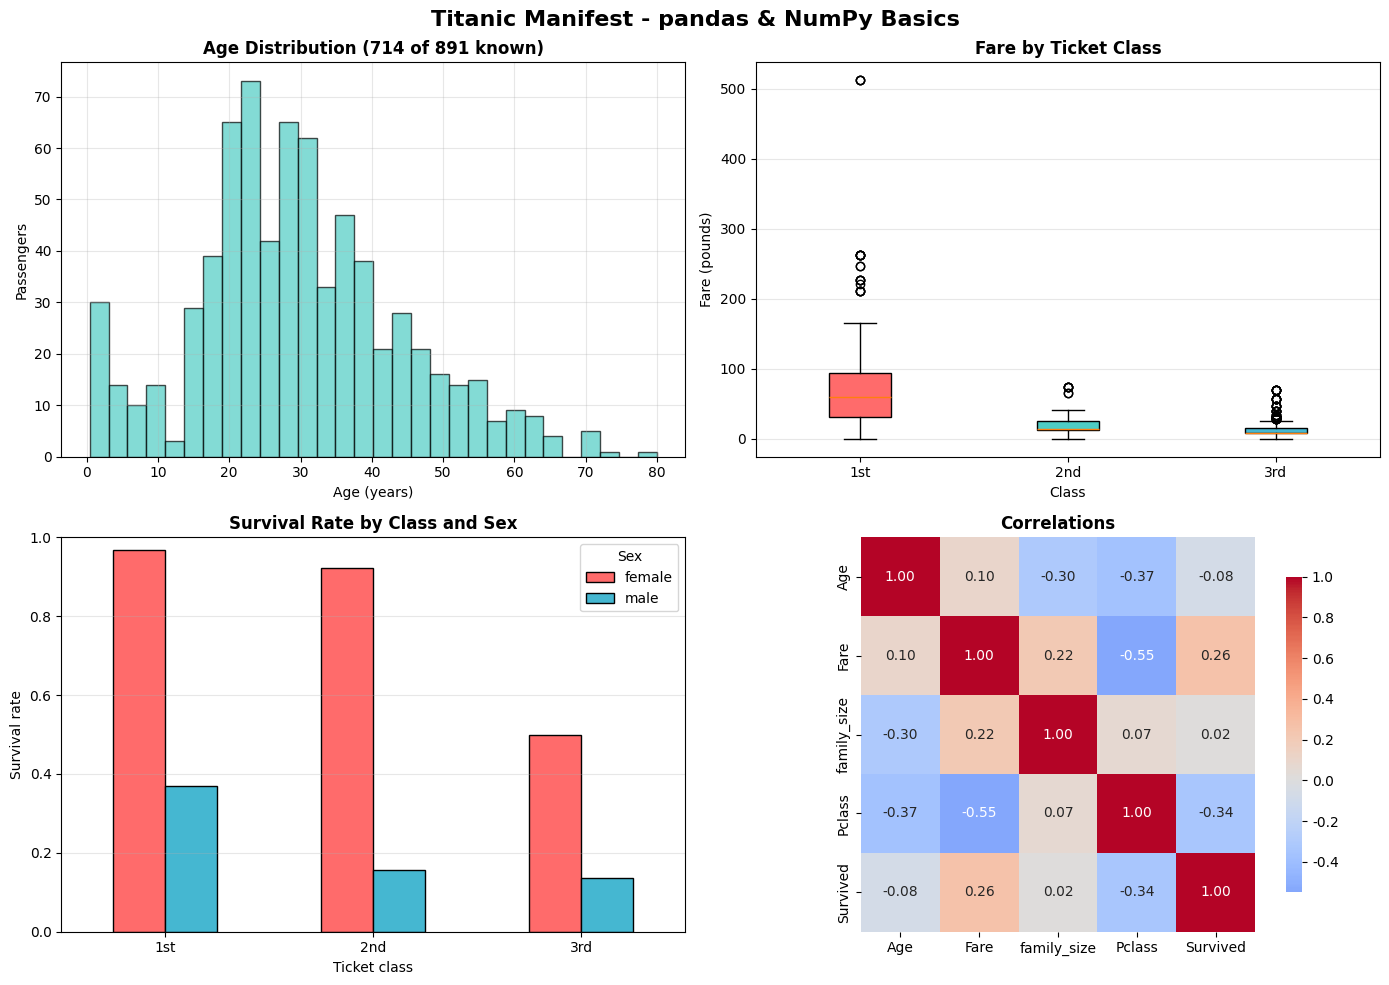

In [8]:
# WHAT: Draw four plots (histogram, boxplots, grouped bars, correlation heatmap) from the manifest.
# WHY: Each chart answers a different question - distribution, spread, group comparison, and relationships.

print("\n\n5. Creating Visualizations")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic Manifest - pandas & NumPy Basics', fontsize=16, weight='bold')

# Plot 1: Age distribution
# dropna() is required: matplotlib cannot bin missing values.
axes[0, 0].hist(df['Age'].dropna(), bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f"Age Distribution ({df['Age'].notna().sum()} of {len(df)} known)",
                     fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Passengers')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Fare spread per class
# A boxplot per class shows medians AND the extreme fares in one picture.
fare_by_class = [df.loc[df['Pclass'] == c, 'Fare'].values for c in (1, 2, 3)]
bp = axes[0, 1].boxplot(fare_by_class, tick_labels=['1st', '2nd', '3rd'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    patch.set_facecolor(color)
axes[0, 1].set_title('Fare by Ticket Class', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Fare (pounds)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Survival rate by class and sex
# unstack() turns the second grouping level into columns so plot() draws grouped bars.
surv = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
surv.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#45B7D1'], edgecolor='black')
axes[1, 0].set_title('Survival Rate by Class and Sex', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Ticket class')
# Pclass is stored as 1/2/3; spell the labels out and un-rotate them so the bars stay readable.
axes[1, 0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
axes[1, 0].set_ylabel('Survival rate')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend(title='Sex', loc='best')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Correlation heatmap
# corr() uses only rows where BOTH columns are present - another quiet effect of missing data.
corr = df[['Age', 'Fare', 'family_size', 'Pclass', 'Survived']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Correlations', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('pandas_numpy_basics.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved as 'pandas_numpy_basics.png'")
print(f"   Pclass vs Survived correlation: {corr.loc['Pclass', 'Survived']:.2f}"
      " (negative: a HIGHER class number = a worse class = lower survival)")
print(f"   Fare vs Survived correlation:   {corr.loc['Fare', 'Survived']:.2f}")


### 👁️ Read the figure

Four panels, one manifest of 891 passengers, four different questions.

- **Top left — how old were they?** The histogram is drawn from the **714 ages the record
  actually contains**, which is why the panel title says so; the other 177 passengers are not
  in it at all. The mass of the ship is in its twenties and thirties, with a distinct bump of
  small children at the far left — 64 passengers were aged 10 or under.
- **Top right — what did a ticket cost?** One shared pound axis for all three classes, so the
  boxes are directly comparable. Median fares are **£60.29, £14.25 and £8.05** for 1st, 2nd
  and 3rd. The lone circle at the top is real data, not a glitch: three passengers travelling
  on ticket PC 17755 are recorded at **£512.33** each. Resist blaming them for the mean:
  drop all three and the mean fare only falls from **£32.20 to £30.58**, still more than
  twice the median of **£14.45**. It is the whole first-class tail that pulls the mean up,
  not one famous ticket.
- **Bottom left — who survived?** Bars grouped by class and split by sex, on a rate axis from
  0 to 1. **Every** female bar is taller than **every** male bar — third-class women at
  **0.500** still outrank first-class men at **0.369** — and within each sex the rate falls
  with class: **0.968 / 0.921 / 0.500** for women, **0.369 / 0.157 / 0.135** for men.
- **Bottom right — what moves with what?** A correlation matrix, red for positive and blue
  for negative, with every coefficient printed in its own cell. `Pclass` vs `Survived` is
  **-0.34**, negative because a *higher* class number means a *worse* cabin; `Fare` vs
  `Survived` is **+0.26**; `family_size` vs `Survived` is **+0.02**, which is to say nothing
  at all. Read the colourbar before the colours: it runs from this matrix's own most
  negative value (**-0.55**, `Pclass` against `Fare`) up to **+1.00** on the diagonal, so the
  shades are set by *this* data — never compare colour intensity between two heatmaps.

**What it proves:** the survival gaps you printed with two lines of `groupby` are not an
artefact of how you sliced the table — they survive being drawn four different ways. It also
shows the limit of a correlation coefficient: **-0.34** is one number for class, but only the
bottom-left panel reveals that it is a sex effect and a class effect stacked on each other,
which is exactly what Discussion question 1 above asks you to disentangle.


## 🎯 Summary: What We Learned

In [9]:
# WHAT: Print a recap of the pandas/NumPy skills covered here.
# WHY: A written summary helps you self-check before the next example builds on these skills.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You knew Python but not pandas or NumPy")
print("   - You didn't know how to manipulate data efficiently")
print("   - You couldn't aggregate or visualize data easily")

print("\n✅ AFTER this notebook:")
print("   - You can create and manipulate NumPy arrays (fast numerical computing)")
print("   - You can load a real CSV into a pandas DataFrame and inspect it")
print("   - You can select, filter, and transform data")
print("   - You can aggregate data using GroupBy")
print("   - You can create visualizations to see patterns")

print("\n📚 Key Concepts Covered:")
print("   1. NumPy Arrays (1D, 2D, operations, statistics)")
print("   2. pandas DataFrames (loading a real CSV, manipulation, selection)")
print("   3. Data Operations (filtering, adding columns, statistics)")
print("   4. GroupBy Operations (survival rates by class and by sex)")
print("   5. Data Visualizations (histograms, box plots, bar charts, heatmaps)")

print("\n🔗 Where These Skills Fit:")
print("   - NumPy: Foundation for all numerical computing")
print("   - pandas: Essential for working with real-world data")
print("   - These skills are used in EVERY data science project!")

print("\n➡️  Next Steps:")
print("   - Continue to Example 3: cuDF Introduction (GPU-accelerated pandas)")
print("   - You'll see the cuDF API and when GPU acceleration helps (needs an NVIDIA GPU)")
print("   - This builds on pandas knowledge from this notebook!")

print("\n" + "=" * 70)



🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You knew Python but not pandas or NumPy
   - You didn't know how to manipulate data efficiently
   - You couldn't aggregate or visualize data easily

✅ AFTER this notebook:
   - You can create and manipulate NumPy arrays (fast numerical computing)
   - You can load a real CSV into a pandas DataFrame and inspect it
   - You can select, filter, and transform data
   - You can aggregate data using GroupBy
   - You can create visualizations to see patterns

📚 Key Concepts Covered:
   1. NumPy Arrays (1D, 2D, operations, statistics)
   2. pandas DataFrames (loading a real CSV, manipulation, selection)
   3. Data Operations (filtering, adding columns, statistics)
   4. GroupBy Operations (survival rates by class and by sex)
   5. Data Visualizations (histograms, box plots, bar charts, heatmaps)

🔗 Where These Skills Fit:
   - NumPy: Foundation for all numerical computing
   - pandas: Essential for working with real-world data
   - The

## 🚫 When pandas Hits a Dead End

**BEFORE**: We've learned pandas and NumPy for data manipulation.

**AFTER**: We discover where pandas actually gets slow — and measure it honestly!

---

### The Problem We've Discovered

We've learned:
- ✅ How to use pandas for data manipulation
- ✅ How to use NumPy for numerical operations
- ✅ How to filter, group, and transform data

**But here is a surprise worth measuring:**
- pandas' *vectorized* operations are FAST — even 1 million rows take a fraction of a second on this machine (we'll verify below)
- The real dead end appears when you process rows **one at a time in Python**: `df.apply(..., axis=1)`, `iterrows()`, or plain `for` loops
- The same computation can be **hundreds of times slower** written row-by-row — the cell below measures the gap on 1,000,000 rows and extrapolates it: at a hundred million rows, thousandths of a second become minutes

**The Dead End:**
- Row-by-row Python code does not scale — this is a genuine, measurable wall
- Even fully vectorized pandas runs on a single CPU core for most operations, which eventually limits you on multi-gigabyte data

---

### Demonstrating the Problem (with real measurements)

891 passengers will not stress anything, so we switch datasets for the benchmark:
**CIC-IDS2017**, a public network-intrusion capture. We read the first **1,000,000 real
network flows** and compute one derived column — packets per second — three ways,
timing each honestly.


In [10]:
# WHAT: Time the SAME computation three ways on 1M REAL network flows - vectorized, Series.apply, and row-by-row apply.
# WHY: Measuring (not guessing) shows row-by-row Python is the real bottleneck, motivating vectorized thinking.

print("\n" + "=" * 70)
print("🚫 THE REAL DEAD END: Row-by-Row Processing in pandas")
print("=" * 70)

import time

# Load 1 million real flows. usecols keeps only the 4 columns we need out of 79, and
# nrows stops after the first million rows - which is how a 707 MB file fits in memory here.
print("\n📊 Loading 1,000,000 real network flows (CIC-IDS2017)...")
large_n = 1_000_000
large_df = pd.read_csv(
    DATA_DIR + 'cicids2017.csv',
    nrows=large_n,
    usecols=[' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', ' Label'],
)
# The published CSV has a leading space in most column names - strip them once, here.
large_df.columns = [c.strip() for c in large_df.columns]
large_df['total_packets'] = large_df['Total Fwd Packets'] + large_df['Total Backward Packets']
print(f"   Loaded: {large_df.shape[0]:,} rows x {large_df.shape[1]} columns")
print(f"   Traffic labels present: {large_df['Label'].nunique()} "
      f"(e.g. {', '.join(large_df['Label'].value_counts().head(3).index)})")

# The SAME computation, three ways:
# packets_per_second = total_packets / duration_in_seconds, and just total_packets
# when the recorded duration is 0 (which really happens in this capture).

# Way 1: Vectorized (the pandas/NumPy way - whole columns at once)
start = time.time()
duration_s = large_df['Flow Duration'] / 1e6      # the file records microseconds
safe_duration = duration_s.where(duration_s > 0, 1.0)   # avoid dividing by zero
result_vec = np.where(duration_s > 0,
                      large_df['total_packets'] / safe_duration,
                      large_df['total_packets'])
t_vectorized = time.time() - start
print(f"\n1) Vectorized (whole columns at once):  {t_vectorized:.4f} seconds")

# Way 2: Series.apply with a Python function (called once per element)
start = time.time()
result_apply = large_df['Flow Duration'].apply(lambda x: x / 1e6 if x > 0 else 0.0)
t_series_apply = time.time() - start
print(f"2) Series.apply (Python per element):   {t_series_apply:.4f} seconds"
      f"  ({t_series_apply / t_vectorized:.0f}x slower)")

# Way 3: df.apply(axis=1) - a Python function called once PER ROW
start = time.time()
result_rowwise = large_df.apply(
    lambda row: row['total_packets'] / (row['Flow Duration'] / 1e6)
    if row['Flow Duration'] > 0 else float(row['total_packets']),
    axis=1)
t_rowwise = time.time() - start
print(f"3) df.apply(axis=1) (Python per row):   {t_rowwise:.4f} seconds"
      f"  ({t_rowwise / t_vectorized:.0f}x slower)")

# Sanity check: all three routes must agree on the answer, or the comparison is meaningless.
print(f"\n   Same answer from ways 1 and 3? "
      f"{np.allclose(result_vec, result_rowwise.values)}")

# Honest conclusions computed from THESE measurements:
print("\n📊 What we actually measured on this machine:")
print(f"   - Vectorized pandas handled {large_n:,} real rows in {t_vectorized:.4f}s")
print("     -> 1 million rows is NOT slow when you stay vectorized")
print(f"   - The same logic row-by-row took {t_rowwise:.2f}s"
      f" -> {t_rowwise / t_vectorized:.0f}x slower on identical data")
print(f"   - Extrapolating row-by-row to 100 million rows:"
      f" ~{t_rowwise * 100 / 60:.1f} minutes for ONE derived column")

print("\n💡 The Problem:")
print("   - Row-by-row Python code is the real dead end - it does not scale")
print("   - Even vectorized pandas runs on a single CPU core for most operations,")
print("     which becomes the bottleneck on multi-gigabyte datasets")

print("\n" + "=" * 70)



🚫 THE REAL DEAD END: Row-by-Row Processing in pandas

📊 Loading 1,000,000 real network flows (CIC-IDS2017)...


   Loaded: 1,000,000 rows x 5 columns
   Traffic labels present: 7 (e.g. BENIGN, DoS Hulk, FTP-Patator)

1) Vectorized (whole columns at once):  0.0032 seconds
2) Series.apply (Python per element):   0.0771 seconds  (24x slower)


3) df.apply(axis=1) (Python per row):   2.2977 seconds  (718x slower)

   Same answer from ways 1 and 3? True

📊 What we actually measured on this machine:
   - Vectorized pandas handled 1,000,000 real rows in 0.0032s
     -> 1 million rows is NOT slow when you stay vectorized
   - The same logic row-by-row took 2.30s -> 718x slower on identical data
   - Extrapolating row-by-row to 100 million rows: ~3.8 minutes for ONE derived column

💡 The Problem:
   - Row-by-row Python code is the real dead end - it does not scale
   - Even vectorized pandas runs on a single CPU core for most operations,
     which becomes the bottleneck on multi-gigabyte datasets



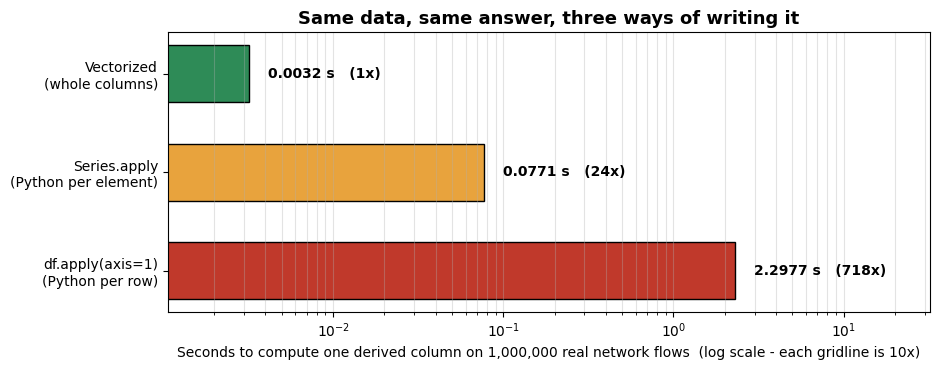

Slowest / fastest = 718x on this machine.
Re-run on your own laptop: the bar lengths will change, the ordering will not.


In [11]:
# WHAT: Put the three timings just measured onto ONE axis so the gap becomes a picture.
# WHY: A several-hundred-fold ratio is a number students nod at; a log-scale bar chart is
#      one they remember. The multiplier printed on each bar is computed, never typed in.
#      Nothing here is re-timed - the bars are exactly the t_* values printed above.

methods = ['Vectorized\n(whole columns)',
           'Series.apply\n(Python per element)',
           'df.apply(axis=1)\n(Python per row)']
times = [t_vectorized, t_series_apply, t_rowwise]
bar_colors = ['#2E8B57', '#E8A33D', '#C0392B']

fig, ax = plt.subplots(figsize=(9.5, 3.8))
bars = ax.barh(methods, times, color=bar_colors, edgecolor='black', height=0.58)

# Why a log axis? The range is ~700x. On a linear axis the fastest bar would be invisible,
# and an invisible bar is a lie by omission.
ax.set_xscale('log')
ax.invert_yaxis()   # fastest on top, so the picture reads in the order you should write code

for bar, t in zip(bars, times):
    ax.text(t * 1.3, bar.get_y() + bar.get_height() / 2,
            f'{t:.4f} s   ({t / t_vectorized:.0f}x)',
            va='center', ha='left', fontsize=10, weight='bold')

ax.set_xlim(t_vectorized / 3.0, t_rowwise * 14)
ax.set_xlabel(f'Seconds to compute one derived column on {large_n:,} real network flows'
              '  (log scale - each gridline is 10x)')
ax.set_title('Same data, same answer, three ways of writing it', fontsize=13, weight='bold')
ax.grid(True, axis='x', alpha=0.35, which='both')
plt.tight_layout()
plt.savefig('vectorization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Slowest / fastest = {t_rowwise / t_vectorized:.0f}x on this machine.")
print("Re-run on your own laptop: the bar lengths will change, the ordering will not.")


### 👁️ Read the figure

- **Three bars, one dataset, one answer.** All three computed packets-per-second for the same
  1,000,000 network flows, and the cell above checked that ways 1 and 3 agree exactly. The
  bars differ only in *how the code was written*.
- **The x-axis is logarithmic, and it has to be.** Each gridline is a 10× step. On a linear
  axis the green bar would be thinner than its own outline — so the picture would hide the
  very thing it is meant to show.
- **The label on each bar is that bar's own measurement**, taken on this machine seconds ago,
  with its multiplier against the vectorized version. The green bar sits roughly three
  gridlines — just under three orders of magnitude — to the left of the red one.

**What it proves:** `df.apply(..., axis=1)` is not a style preference, it is a multiplier on
every row you own, and it does not get better as the data grows. That is why Unit 5 reaches
for Dask, Spark and GPUs *only after* the code is vectorized — buying hardware to make the
red bar faster is paying to avoid a rewrite that takes one line.


## 💬 Discuss

You just measured, on 1,000,000 real network flows, that the identical computation ran in
**a few thousandths of a second** vectorized and **a couple of seconds** row-by-row — a gap of
**several hundred times**, with the exact multiplier printed on the red bar above. Those
timings differ from laptop to laptop; the ordering and the order of magnitude do not.

1. Row-by-row code is slower but often easier to read and debug. Where would you draw the
   line in your own work: at what row count does readability stop being worth the
   several-hundred-fold slowdown you just measured? Defend a number, do not say
   "it depends".
2. The vectorized and row-by-row versions returned the *same answer* here (the notebook
   checks). Name a computation where they would **not** — where you genuinely need to see
   one row at a time. If you cannot think of one, that is itself the point worth arguing.
3. Your client's dataset is 40 GB and the machine has 16 GB of RAM. Vectorizing does not
   help — the file will not load at all. Before spending money on a bigger machine or a
   GPU, what is the first thing you would try, and what would you have to give up?


### What We Need Next

**Lesson 1 — Vectorize first (the free speedup we just measured):**
The same computation ran hundreds of times faster as whole-column operations. Before reaching for new hardware, always replace row-by-row Python with vectorized pandas/NumPy.

**Lesson 2 — When even vectorized CPU isn't enough:**
Most pandas operations use a single CPU core. On multi-gigabyte datasets with heavy joins, groupbys, and sorts, that single core becomes the bottleneck — and parallel hardware can help:
- **cuDF**: a GPU dataframe library with a pandas-identical API
- **Requires an NVIDIA GPU** — published RAPIDS benchmarks (NVIDIA, rapids.ai) report large speedups on multi-gigabyte workloads

**This leads us to Example 3: cuDF Introduction**
- Example 3 shows the cuDF API side by side with pandas
- It measures real CPU baselines and cites published GPU benchmarks with their source
- Note: this teaching machine has no NVIDIA GPU, so Example 3 shows the API without fabricating GPU timings

## ⚠️ Where this breaks

pandas and NumPy are the right default, and they have hard edges you should be able to
name before an interviewer names them for you:

- **The whole file must fit in RAM — with room to spare.** This notebook could not simply
  `read_csv` the CIC-IDS2017 capture: it passes `usecols` and `nrows` to take the first
  1,000,000 rows and 4 of the 79 columns (`total_packets`, the fifth in the frame, is
  computed here rather than read). Rule of thumb: pandas wants several times the file size in
  memory, because intermediate results are copies. Units 5's Dask and Spark lessons exist
  for the day this stops being enough.
- **One core, most of the time.** The vectorized time above is one CPU core running
  optimised C.
  Buying a 64-core machine will not make that groupby 64× faster; almost nothing in core
  pandas is parallel.
- **NaN silently changes your dtype.** `Age` in this manifest is `float64`, not `int64`,
  purely because 177 values are missing — NumPy's classic integer arrays have no "missing".
  If you assume ages are integers downstream, that assumption is already false here.
- **`object` dtype is a trap door.** `Name`, `Ticket` and `Cabin` are stored as `object`,
  meaning a NumPy array of Python pointers. Operations on them fall back to Python speed —
  the several-hundred-fold penalty comes back through the side door even in
  "vectorized" code.
- **When to reach for something else:** if the data already lives in a database, a SQL
  `GROUP BY` on the server beats pulling 40 GB across the network to group it in pandas.
  If the task is a one-line filter on a text file, `awk` or `duckdb` will beat both. Use
  pandas when the analysis is exploratory, iterative and needs to be read by a human later.

**The same shape of problem elsewhere:** a genomics lab whose gene names were auto-converted
to dates by a spreadsheet; a bank reconciling ledgers whose account IDs lost their leading
zeros on import; a survey team whose "N/A" answers turned an integer column into text. In
every case the tool was silent, not wrong — which is why it took months to notice.


## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>
3. McKinney, W. (2017). *Python for Data Analysis*, 2nd ed. O'Reilly Media.
4. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
5. Kumar, P., Imran, A., & Kosar, T. (2025). *Energy Consumption of Dataframe Libraries for End-to-End Deep Learning Pipelines: A Comparative Analysis*. arXiv:2511.08644. <https://arxiv.org/abs/2511.08644>
